# Convolutional Neural networks

In this notebook, we will look closer at Convolutional Neural networks (CNN) for image classification. We will show how a CNN can improve our previous model for classifying handwritten digits in the MNIST dataset. This is based on the following code example from the keras website: [https://keras.io/examples/vision/mnist_convnet/](/https://keras.io/examples/vision/mnist_convnet/).

First, however, we will redo the model from chapter 2 of the book. 

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers

2026-03-04 10:52:24.669837: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-04 10:52:24.669906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-04 10:52:24.673515: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 10:52:24.688971: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


In [5]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

2026-03-04 10:52:32.245045: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1926] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20582 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:02:00.0, compute capability: 8.9


In [6]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [7]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [8]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5


2026-03-04 10:52:34.400117: I external/local_xla/xla/service/service.cc:168] XLA service 0x561b13158700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 10:52:34.400160: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2026-03-04 10:52:34.410533: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 10:52:34.451292: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90000
I0000 00:00:1772621554.566590    1048 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 [==============================] - 3s 3ms/step - loss: 0.2655 - accuracy: 0.9250
Epoch 2/5
469/469 [==============================] - 1s 3ms/step - loss: 0.1080 - accuracy: 0.9691
Epoch 3/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0705 - accuracy: 0.9794
Epoch 4/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0497 - accuracy: 0.9858
Epoch 5/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0370 - accuracy: 0.9894


In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407050 (1.55 MB)
Trainable params: 407050 (1.55 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 [==============================] - 1s 2ms/step - loss: 0.0651 - accuracy: 0.9800
test_acc: 0.9800000190734863


## Building a CNN model for the MNIST dataset

Now, let us build a CNN model on the same data

In [11]:
num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dropout (Dropout)           (None, 1600)             

Before we can train it, we need the data in the right format for CNN. For CNN models, we do not need to reshape or flatten our images thus, the only preprocessing we need is the one below.

In [12]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [13]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [14]:
y_test.shape

(10000, 10)

Now, let us train the model.

In [15]:
batch_size = 128
epochs = 15

model.compile(optimizer="adam", 
              loss="categorical_crossentropy", 
              metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
422/422 [==============================] - 5s 6ms/step - loss: 0.3625 - accuracy: 0.8896 - val_loss: 0.0782 - val_accuracy: 0.9775
Epoch 2/15
422/422 [==============================] - 2s 5ms/step - loss: 0.1108 - accuracy: 0.9655 - val_loss: 0.0559 - val_accuracy: 0.9847
Epoch 3/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0838 - accuracy: 0.9742 - val_loss: 0.0450 - val_accuracy: 0.9888
Epoch 4/15
422/422 [==============================] - 2s 4ms/step - loss: 0.0727 - accuracy: 0.9768 - val_loss: 0.0424 - val_accuracy: 0.9885
Epoch 5/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0624 - accuracy: 0.9807 - val_loss: 0.0390 - val_accuracy: 0.9895
Epoch 6/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0577 - accuracy: 0.9816 - val_loss: 0.0358 - val_accuracy: 0.9903
Epoch 7/15
422/422 [==============================] - 2s 5ms/step - loss: 0.0539 - accuracy: 0.9833 - val_loss: 0.0390 - val_accuracy: 0.9877
Epoch 

Finally, we can evaluate the model.

In [16]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.026335693895816803
Test accuracy: 0.9908999800682068


Our original model was already fairly good, but we managed to improve it relatively significantly, to a production quality. However, the CNN model took much longer to train, which also have to be taken into account. In other, more complicated image classification tasks, CNNs have turned out to be really well performing.

## Cat vs dog CNN

In this section we will look at building a CNN to classify images of cats or dogs. It is based on a famous kaggle dataset available here: [https://www.kaggle.com/c/dogs-vs-cats/data](https://www.kaggle.com/c/dogs-vs-cats/data). We will, however, only look at a small subset of the dataset (1200 training images, 200 validation images, and 600 test images), which is also available on the course moodle page.

We first need to load the various datasets in (and process them properly). Luckily, Keras has utility functions that makes this easy.

In [17]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    "dogs_vs_cats_tiny/train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    "dogs_vs_cats_tiny/validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    "dogs_vs_cats_tiny/test", image_size=image_size, batch_size=batch_size
)

Found 1200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Found 600 files belonging to 2 classes.


Let us now build a CNN models to classify cats vs dogs.

In [18]:
c_and_d_model = keras.Sequential(
    [
        keras.Input(shape=(180, 180, 3)),
        layers.Rescaling(1.0/255),
        layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(filters=256, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(1, activation="sigmoid"),
    ]
)
c_and_d_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 41, 41, 128)      

And let us compile it.

In [19]:
c_and_d_model.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

And let us finally fit it.

In [20]:
history = c_and_d_model.fit(
    train_dataset,
    epochs=40,  # I have already checked when to stop...
    validation_data=validation_dataset)

Epoch 1/40
19/19 [==============================] - 11s 312ms/step - loss: 0.6944 - accuracy: 0.5150 - val_loss: 0.6908 - val_accuracy: 0.5200
Epoch 2/40
19/19 [==============================] - 2s 123ms/step - loss: 0.6850 - accuracy: 0.5508 - val_loss: 0.6952 - val_accuracy: 0.4900
Epoch 3/40
19/19 [==============================] - 1s 68ms/step - loss: 0.6714 - accuracy: 0.5700 - val_loss: 0.6931 - val_accuracy: 0.5250
Epoch 4/40
19/19 [==============================] - 1s 72ms/step - loss: 0.6700 - accuracy: 0.5908 - val_loss: 0.6860 - val_accuracy: 0.5300
Epoch 5/40
19/19 [==============================] - 1s 55ms/step - loss: 0.6635 - accuracy: 0.5758 - val_loss: 0.6801 - val_accuracy: 0.5600
Epoch 6/40
19/19 [==============================] - 1s 50ms/step - loss: 0.6545 - accuracy: 0.6008 - val_loss: 0.6753 - val_accuracy: 0.5850
Epoch 7/40
19/19 [==============================] - 1s 52ms/step - loss: 0.6420 - accuracy: 0.6158 - val_loss: 0.6534 - val_accuracy: 0.5900
Epoch 8/40

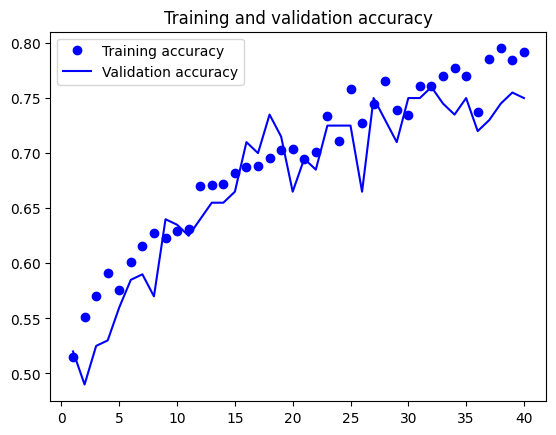

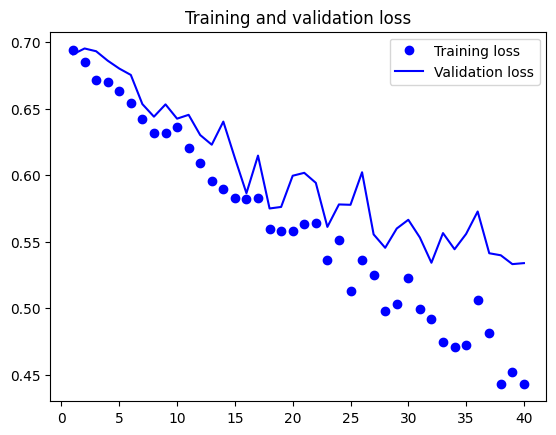

In [21]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [22]:
test_loss, test_acc = c_and_d_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

10/10 [==============================] - 1s 52ms/step - loss: 0.5930 - accuracy: 0.7283
Test accuracy: 0.728
